## Exercise 3 (Matrix Transpose)

### a) `transpose.cc`

## Machine information

| Property | Machine |
|---|---|
| CPU model | Intel Core i5-10300H (Comet Lake-H, 14 nm) |
| Cores / threads | 4 / 8, SMT enabled |
| Base clock | 2.5 GHz |
| Turbo clock | up to 4.5 GHz, 1-core |
| L1 cache | 32 KB instruction + 32 KB data per core, 8-way |
| L2 cache | 256 KB per core, 4-way |
| L3 cache | 8 MB shared, 16-way |
| Cache line size | 64 B |
| DRAM | 16 GB DDR4-2933, dual channel |
| Theoretical peak memory bandwidth | 46.9 GB/s |
| Vector ISA | SSE, SSE2, SSE4.1, SSE4.2, AVX, AVX2, FMA |
| Max SIMD width | 256-bit, 4 doubles per vector |


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_file = Path("results/transpose_results.csv")
df = pd.read_csv(csv_file)
df.head()


,strategy,N,block_size,repetitions,runtime_ms,bandwidth_GBps,checksum
0,consecutive-write,256,0,512,0.212156,4.942,25296384.0
1,strided-write,256,0,256,0.443066,2.367,25296384.0
2,blocked-consecutive-write,256,4,1024,0.178873,5.862,25296384.0
3,blocked-strided-write,256,4,1024,0.119861,8.748,25296384.0
4,blocked-consecutive-write,256,8,2048,0.084710,12.378,25296384.0


## Runtime table


In [12]:
runtime_table = df[["strategy", "N", "block_size", "runtime_ms"]].copy()
runtime_table.sort_values(["N", "strategy", "block_size"])


,strategy,N,block_size,runtime_ms
2,blocked-consecutive-write,256,4,0.178873
4,blocked-consecutive-write,256,8,0.084710
6,blocked-consecutive-write,256,16,0.043931
8,blocked-consecutive-write,256,24,0.049189
10,blocked-consecutive-write,256,32,0.052019
...,...,...,...,...
75,blocked-strided-write,4096,32,68.053000
77,blocked-strided-write,4096,64,76.331000
79,blocked-strided-write,4096,128,71.846500
64,consecutive-write,4096,0,328.617000


In [13]:
best_runtime = (
    df.sort_values("runtime_ms")
      .groupby("N", as_index=False)
      .first()[["N", "strategy", "block_size", "runtime_ms"]]
)
best_runtime


,N,strategy,block_size,runtime_ms
0,256,blocked-consecutive-write,16,0.043931
1,512,blocked-consecutive-write,8,0.219965
2,1024,blocked-consecutive-write,32,1.628062
3,2048,blocked-strided-write,8,9.086812
4,4096,blocked-consecutive-write,32,43.683250


## Runtime plots


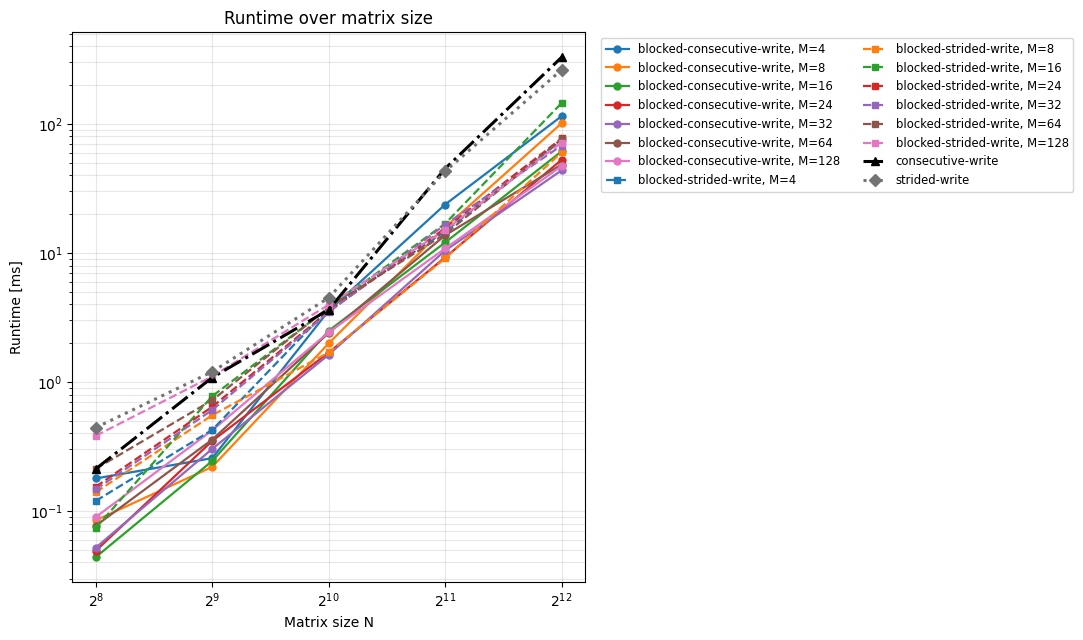

In [14]:
fig, ax = plt.subplots(figsize=(11, 6.5))

block_sizes = sorted(df[df["block_size"] > 0]["block_size"].unique())
colors = dict(zip(block_sizes, plt.cm.tab10(range(len(block_sizes)))))

style = {
    "blocked-consecutive-write": {"linestyle": "-", "marker": "o"},
    "blocked-strided-write": {"linestyle": "--", "marker": "s"},
}

for strategy in ["blocked-consecutive-write", "blocked-strided-write"]:
    for block_size in block_sizes:
        group = df[(df["strategy"] == strategy) & (df["block_size"] == block_size)].sort_values("N")
        ax.plot(
            group["N"],
            group["runtime_ms"],
            color=colors[block_size],
            linestyle=style[strategy]["linestyle"],
            marker=style[strategy]["marker"],
            linewidth=1.6,
            markersize=5,
            label=f"{strategy}, M={block_size}",
        )

baseline_style = {
    "consecutive-write": {"color": "black", "linestyle": "-.", "marker": "^"},
    "strided-write": {"color": "0.45", "linestyle": ":", "marker": "D"},
}

for strategy, spec in baseline_style.items():
    group = df[df["strategy"] == strategy].sort_values("N")
    ax.plot(
        group["N"],
        group["runtime_ms"],
        color=spec["color"],
        linestyle=spec["linestyle"],
        marker=spec["marker"],
        linewidth=2.2,
        markersize=6,
        label=strategy,
    )

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Matrix size N")
ax.set_ylabel("Runtime [ms]")
ax.set_title("Runtime over matrix size")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize="small", ncols=2, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig("results/transpose_runtime_by_size.png", dpi=180, bbox_inches="tight")
plt.show()


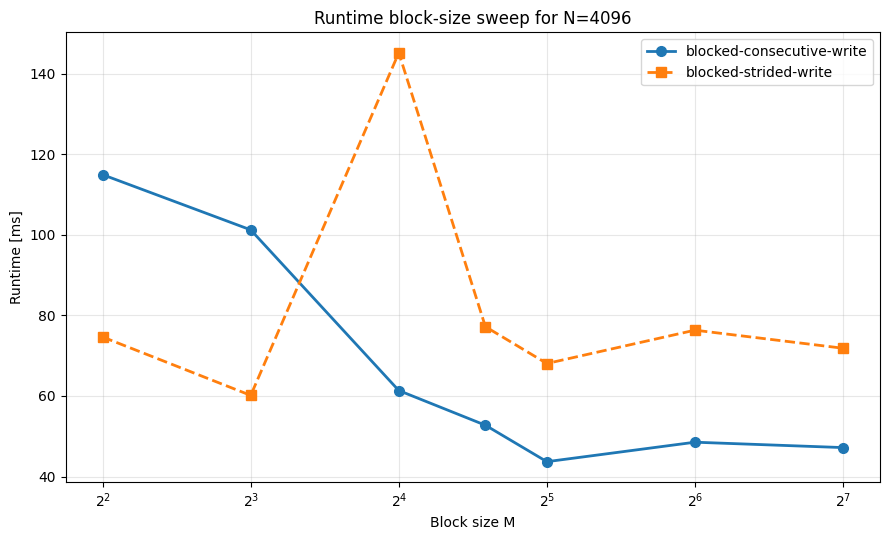

In [15]:
largest_n = df["N"].max()
blocked = df[(df["N"] == largest_n) & (df["block_size"] > 0)].copy()

fig, ax = plt.subplots(figsize=(9, 5.5))

for strategy, spec in style.items():
    group = blocked[blocked["strategy"] == strategy].sort_values("block_size")
    ax.plot(
        group["block_size"],
        group["runtime_ms"],
        color="tab:blue" if strategy == "blocked-consecutive-write" else "tab:orange",
        linestyle=spec["linestyle"],
        marker=spec["marker"],
        linewidth=2,
        markersize=7,
        label=strategy,
    )

ax.set_xscale("log", base=2)
ax.set_xlabel("Block size M")
ax.set_ylabel("Runtime [ms]")
ax.set_title(f"Runtime block-size sweep for N={largest_n}")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("results/transpose_runtime_block_size_sweep.png", dpi=180, bbox_inches="tight")
plt.show()


### Remarks:

The blocked versions are much faster than the unblocked versions for large matrices. This is expected because blocking improves cache locality and avoids jumping through the whole matrix for every access.

For small matrices, the differences are less stable because much of the data still fits into cache. Runtime is then influenced more by loop overhead, measurement noise, and compiler optimizations.

For larger matrices, the best block sizes are around M=8 to M=32. This fits well with the machine’s cache structure.

The cache line size is 64 B, which corresponds to 8 doubles. This explains why M=8 often performs well, since one row of a block matches one cache line.

M=32 is also a good block size on this CPU. Two 32 x 32 blocks of doubles need about 16 KB, which fits comfortably into the 32 KB L1 data cache.

Larger block sizes such as M=64 and M=128 can become worse because their working set no longer fits well into L1 cache. M=128 is already about the size of the whole 256 KB L2 cache when both input and output tiles are considered.

The unblocked consecutive-write version writes efficiently, but reads with a large stride. The unblocked strided-write version reads efficiently, but writes with a large stride. In both cases, one side of the operation has poor cache behavior.
